# Objective 3 — Step 13: Final Ablation, Corrected Statistics, and Taiwan Fairness Audit

The core Objective-3 framework is now frozen:

**Leakage-controlled preprocessing → Group-aware Chi-Square Top-75% → Balanced LR + RF + XGBoost → Equal Soft Voting → Sigmoid Calibration → Cost-aware threshold rule**

The reference threshold rule is:

\[
\text{Choose } t^* = \arg\min_t (FP + 2FN)
\]

using only cross-fitted calibrated OOF probabilities from the training partition.

This notebook does **not tune the framework further**. It consolidates all completed experiments into manuscript-ready evidence.

## Main tasks

1. Build a six-stage cross-dataset ablation table.
2. Compare the final framework with the original all-feature XGBoost baseline.
3. Use the Nadeau–Bengio corrected repeated-CV t-test with Holm adjustment.
4. Produce manuscript-ready summary tables and figures.
5. Perform a Taiwan fairness audit by sex and age group using the frozen final predictions.

## Important interpretation

The FN:FP = 2:1 loss ratio is a **reference asymmetric-loss sensitivity scenario**, not an empirically measured monetary banking cost.

The fairness section is an **audit**, not a claim that the model satisfies a universal definition of fairness.


In [1]:
%pip install pandas numpy scipy scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: C:\Users\hp\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [2]:

from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from scipy.stats import t as student_t

warnings.filterwarnings("ignore")

BASE_DIR = Path(r"D:\PHD\Research Paper writing\3rd Obj. paper")

RESULTS_DIR = BASE_DIR / "results"
DATA_DIR = BASE_DIR / "data" / "processed"

STEP3_DIR = RESULTS_DIR / "baseline_models"
STEP4_DIR = RESULTS_DIR / "feature_selection_german_development"
STEP5_DIR = RESULTS_DIR / "feature_selection_frozen_replication"
STEP6_DIR = RESULTS_DIR / "cost_sensitive_xgb_ablation"
STEP7_DIR = RESULTS_DIR / "ensemble_german_development"
STEP8_DIR = RESULTS_DIR / "frozen_hybrid_ensemble_replication"
STEP9_DIR = RESULTS_DIR / "calibration_german_development"
STEP10_DIR = RESULTS_DIR / "frozen_sigmoid_calibration_replication"
STEP11_DIR = RESULTS_DIR / "threshold_german_development"
STEP12_DIR = RESULTS_DIR / "frozen_cost_aware_threshold_replication"

OUT_DIR = RESULTS_DIR / "final_synthesis_statistics_fairness"
FIG_DIR = OUT_DIR / "figures"

OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

FILES = {
    "baseline": STEP3_DIR / "baseline_fold_results_all.csv",
    "baseline_predictions": STEP3_DIR / "baseline_predictions_all.csv",
    "german_fs": STEP4_DIR / "german_feature_selection_fold_results.csv",
    "external_fs": STEP5_DIR / "frozen_replication_fold_results.csv",
    "cost_ablation": STEP6_DIR / "cost_sensitive_xgb_fold_results.csv",
    "german_ensemble": STEP7_DIR / "german_ensemble_fold_results.csv",
    "external_ensemble": STEP8_DIR / "frozen_hybrid_fold_results.csv",
    "german_calibration": STEP9_DIR / "german_calibration_fold_results.csv",
    "external_calibration": STEP10_DIR / "frozen_sigmoid_replication_fold_results.csv",
    "german_threshold": STEP11_DIR / "german_threshold_outer_fold_results.csv",
    "external_threshold": STEP12_DIR / "frozen_cost_aware_threshold_fold_results.csv",
    "external_final_predictions": STEP12_DIR / "frozen_cost_aware_outer_predictions.csv",
    "taiwan": DATA_DIR / "taiwan_credit_card_default_cleaned.csv",
}

missing = [str(path) for path in FILES.values() if not path.exists()]

if missing:
    raise FileNotFoundError(
        "Required previous-step files are missing:\n"
        + "\n".join(missing)
    )

DATASET_ORDER = [
    "German Credit",
    "Australian Credit Approval",
    "Taiwan Credit Card Default",
]

STAGE_ORDER = [
    "A0_Baseline_XGB",
    "A1_FrozenFS_XGB",
    "A2_FrozenFS_BalancedXGB",
    "A3_Hybrid_SoftVote",
    "A4_Hybrid_Sigmoid",
    "A5_Full_CostAware",
]

STAGE_LABELS = {
    "A0_Baseline_XGB": "A0 Baseline XGB",
    "A1_FrozenFS_XGB": "A1 + Frozen FS",
    "A2_FrozenFS_BalancedXGB": "A2 + Balanced XGB",
    "A3_Hybrid_SoftVote": "A3 + Hybrid Vote",
    "A4_Hybrid_Sigmoid": "A4 + Sigmoid",
    "A5_Full_CostAware": "A5 + Cost-aware threshold",
}

print("Output folder:", OUT_DIR)


Output folder: D:\PHD\Research Paper writing\3rd Obj. paper\results\final_synthesis_statistics_fairness


## 1. Load all completed experiment outputs

In [3]:

baseline = pd.read_csv(FILES["baseline"])
german_fs = pd.read_csv(FILES["german_fs"])
external_fs = pd.read_csv(FILES["external_fs"])
cost_ablation = pd.read_csv(FILES["cost_ablation"])
german_ensemble = pd.read_csv(FILES["german_ensemble"])
external_ensemble = pd.read_csv(FILES["external_ensemble"])
german_calibration = pd.read_csv(FILES["german_calibration"])
external_calibration = pd.read_csv(FILES["external_calibration"])
german_threshold = pd.read_csv(FILES["german_threshold"])
external_threshold = pd.read_csv(FILES["external_threshold"])
final_predictions_external = pd.read_csv(FILES["external_final_predictions"])
taiwan = pd.read_csv(FILES["taiwan"])

print("Loaded all Step 3–12 result tables.")


Loaded all Step 3–12 result tables.


## 2. Harmonize fold-level metrics

The ablation stages are:

- **A0**: all-feature unweighted XGBoost baseline
- **A1**: frozen Group-aware Chi-Square Top-75% + unweighted XGBoost
- **A2**: frozen feature selection + balanced XGBoost
- **A3**: frozen feature selection + balanced heterogeneous soft-voting hybrid
- **A4**: A3 + sigmoid probability calibration, threshold 0.50
- **A5**: complete framework + training-derived MinCost FN:FP = 2:1 threshold

Threshold-independent ROC-AUC and PR-AUC for A5 are inherited from A4 because changing a decision threshold does not change probability ranking.


In [4]:

CORE_METRICS = [
    "accuracy",
    "precision_adverse",
    "recall_adverse",
    "specificity",
    "f1_adverse",
    "balanced_accuracy",
    "mcc",
    "roc_auc",
    "pr_auc",
    "gmean",
]

def add_costs_from_confusion(frame):
    frame = frame.copy()

    n = (
        frame["tn"]
        + frame["fp"]
        + frame["fn"]
        + frame["tp"]
    )

    for fn_cost in [1, 2, 5, 10]:
        frame[f"cost_FN{fn_cost}_FP1_per100"] = (
            100.0
            * (
                frame["fp"]
                + fn_cost * frame["fn"]
            )
            / n
        )

    return frame


def standardize_stage(frame, stage_name):
    frame = add_costs_from_confusion(frame)

    keep = [
        "dataset",
        "run_id",
        "repeat",
        "fold",
        *CORE_METRICS,
        "tn",
        "fp",
        "fn",
        "tp",
        "cost_FN1_FP1_per100",
        "cost_FN2_FP1_per100",
        "cost_FN5_FP1_per100",
        "cost_FN10_FP1_per100",
    ]

    out = frame[keep].copy()
    out["stage"] = stage_name
    return out


# A0
a0 = baseline[
    baseline["model"] == "XGB"
].copy()
a0 = standardize_stage(
    a0,
    "A0_Baseline_XGB",
)


# A1: German Step 4 + external Step 5
a1_g = german_fs[
    (german_fs["selector"] == "Chi2")
    & (german_fs["subset"] == "Top75")
].copy()
a1_g["dataset"] = "German Credit"

a1_e = external_fs.copy()

a1 = standardize_stage(
    pd.concat(
        [a1_g, a1_e],
        ignore_index=True,
        sort=False,
    ),
    "A1_FrozenFS_XGB",
)


# A2: frozen FS + balanced XGB
a2 = cost_ablation[
    (cost_ablation["feature_regime"] == "FrozenChi2Top75")
    & (cost_ablation["weight_strategy"] == "Balanced")
].copy()

a2 = standardize_stage(
    a2,
    "A2_FrozenFS_BalancedXGB",
)


# A3: German Step 7 + external Step 8
a3_g = german_ensemble[
    (german_ensemble["feature_regime"] == "FrozenChi2Top75")
    & (german_ensemble["training_regime"] == "Balanced")
    & (german_ensemble["ensemble_type"] == "SoftVote")
].copy()

a3_e = external_ensemble.copy()

a3 = standardize_stage(
    pd.concat(
        [a3_g, a3_e],
        ignore_index=True,
        sort=False,
    ),
    "A3_Hybrid_SoftVote",
)


# A4: sigmoid calibrated hybrid at threshold 0.50
a4_g = german_calibration[
    german_calibration["calibration_method"] == "Sigmoid"
].copy()

a4_e = external_calibration[
    external_calibration["calibration_method"] == "Sigmoid"
].copy()

a4 = standardize_stage(
    pd.concat(
        [a4_g, a4_e],
        ignore_index=True,
        sort=False,
    ),
    "A4_Hybrid_Sigmoid",
)


# A5: final threshold results.
a5_g = german_threshold[
    german_threshold["threshold_strategy"] == "MinCost_FN2_FP1"
].copy()

a5_g["dataset"] = "German Credit"

a5_e = external_threshold[
    external_threshold["threshold_strategy"] == "MinCost_FN2_FP1"
].copy()

a5_threshold = pd.concat(
    [a5_g, a5_e],
    ignore_index=True,
    sort=False,
)

# Attach A4 ranking metrics because thresholding does not change them.
a4_ranking = a4[
    ["dataset", "run_id", "roc_auc", "pr_auc"]
].copy()

a5_threshold = a5_threshold.drop(
    columns=[
        column
        for column in ["roc_auc", "pr_auc"]
        if column in a5_threshold.columns
    ],
    errors="ignore",
)

a5_threshold = a5_threshold.merge(
    a4_ranking,
    on=["dataset", "run_id"],
    how="left",
    validate="one_to_one",
)

a5 = standardize_stage(
    a5_threshold,
    "A5_Full_CostAware",
)


ablation_fold = pd.concat(
    [a0, a1, a2, a3, a4, a5],
    ignore_index=True,
)

ablation_fold["dataset"] = pd.Categorical(
    ablation_fold["dataset"],
    categories=DATASET_ORDER,
    ordered=True,
)

ablation_fold["stage"] = pd.Categorical(
    ablation_fold["stage"],
    categories=STAGE_ORDER,
    ordered=True,
)

ablation_fold = ablation_fold.sort_values(
    ["dataset", "stage", "run_id"]
).reset_index(drop=True)

ablation_fold.to_csv(
    OUT_DIR / "final_ablation_fold_level.csv",
    index=False,
)

print("Ablation fold rows:", len(ablation_fold))
print(
    ablation_fold.groupby(
        ["dataset", "stage"],
        observed=True,
    ).size()
)


Ablation fold rows: 450
dataset                     stage                  
German Credit               A0_Baseline_XGB            25
                            A1_FrozenFS_XGB            25
                            A2_FrozenFS_BalancedXGB    25
                            A3_Hybrid_SoftVote         25
                            A4_Hybrid_Sigmoid          25
                            A5_Full_CostAware          25
Australian Credit Approval  A0_Baseline_XGB            25
                            A1_FrozenFS_XGB            25
                            A2_FrozenFS_BalancedXGB    25
                            A3_Hybrid_SoftVote         25
                            A4_Hybrid_Sigmoid          25
                            A5_Full_CostAware          25
Taiwan Credit Card Default  A0_Baseline_XGB            25
                            A1_FrozenFS_XGB            25
                            A2_FrozenFS_BalancedXGB    25
                            A3_Hybrid_SoftVote        

## 3. Manuscript-ready ablation table

In [5]:

ablation_summary = (
    ablation_fold
    .groupby(
        ["dataset", "stage"],
        observed=True,
        as_index=False,
    )
    .agg(
        ROC_AUC=("roc_auc", "mean"),
        PR_AUC=("pr_auc", "mean"),
        Recall=("recall_adverse", "mean"),
        Precision=("precision_adverse", "mean"),
        F1=("f1_adverse", "mean"),
        Balanced_Accuracy=("balanced_accuracy", "mean"),
        MCC=("mcc", "mean"),
        GMean=("gmean", "mean"),
        Cost_2_1=("cost_FN2_FP1_per100", "mean"),
        Cost_5_1=("cost_FN5_FP1_per100", "mean"),
        Cost_10_1=("cost_FN10_FP1_per100", "mean"),
    )
)

ablation_summary["Stage_Label"] = (
    ablation_summary["stage"]
    .astype(str)
    .map(STAGE_LABELS)
)

ablation_summary.to_csv(
    OUT_DIR / "manuscript_ready_ablation_table.csv",
    index=False,
)

for dataset_name in DATASET_ORDER:
    print("\n", dataset_name)
    display(
        ablation_summary[
            ablation_summary["dataset"] == dataset_name
        ][
            [
                "Stage_Label",
                "ROC_AUC",
                "PR_AUC",
                "Recall",
                "F1",
                "Balanced_Accuracy",
                "MCC",
                "Cost_2_1",
            ]
        ]
    )



 German Credit


,Stage_Label,ROC_AUC,PR_AUC,Recall,F1,Balanced_Accuracy,MCC,Cost_2_1
0,A0 Baseline XGB,0.790369,0.632366,0.478338,0.544334,0.681676,0.398821,39.30
1,A1 + Frozen FS,0.788434,0.622283,0.490576,0.547579,0.683953,0.398727,39.22
2,A2 + Balanced XGB,0.787275,0.619312,0.641251,0.598078,0.714983,0.415944,36.32
3,A3 + Hybrid Vote,0.798802,0.634897,0.626506,0.603075,0.718355,0.428590,35.78
4,A4 + Sigmoid,0.798802,0.634897,0.464135,0.536208,0.677750,0.395607,39.86
5,A5 + Cost-aware threshold,0.798802,0.634897,0.689360,0.608808,0.723812,0.425318,35.72



 Australian Credit Approval


,Stage_Label,ROC_AUC,PR_AUC,Recall,F1,Balanced_Accuracy,MCC,Cost_2_1
6,A0 Baseline XGB,0.931568,0.932837,0.878958,0.883336,0.872130,0.742331,19.565217
7,A1 + Frozen FS,0.925940,0.930499,0.871046,0.873366,0.859510,0.717740,21.159420
8,A2 + Balanced XGB,0.926164,0.929792,0.861221,0.871964,0.860281,0.718390,21.681159
9,A3 + Hybrid Vote,0.931624,0.938131,0.856447,0.876949,0.869179,0.734673,21.217391
10,A4 + Sigmoid,0.931624,0.938131,0.864474,0.877628,0.867758,0.732658,20.840580
11,A5 + Cost-aware threshold,0.931624,0.938131,0.918994,0.872189,0.843862,0.702414,19.391304



 Taiwan Credit Card Default


,Stage_Label,ROC_AUC,PR_AUC,Recall,F1,Balanced_Accuracy,MCC,Cost_2_1
12,A0 Baseline XGB,0.783234,0.560525,0.367964,0.475333,0.658417,0.402911,31.946002
13,A1 + Frozen FS,0.782617,0.560105,0.366999,0.475385,0.658392,0.404185,31.917332
14,A2 + Balanced XGB,0.782551,0.559242,0.629868,0.538683,0.714306,0.389748,32.049967
15,A3 + Hybrid Vote,0.777340,0.557204,0.509745,0.539777,0.701085,0.420070,30.068667
16,A4 + Sigmoid,0.777340,0.557204,0.363076,0.472411,0.656856,0.402540,32.024664
17,A5 + Cost-aware threshold,0.777340,0.557204,0.511119,0.538789,0.700782,0.418124,30.163330


## 4. Final proposed framework versus original baseline

In [6]:

baseline_final = ablation_fold[
    ablation_fold["stage"].isin(
        [
            "A0_Baseline_XGB",
            "A5_Full_CostAware",
        ]
    )
].copy()

comparison_rows = []

for dataset_name in DATASET_ORDER:
    base = (
        baseline_final[
            (baseline_final["dataset"] == dataset_name)
            & (baseline_final["stage"] == "A0_Baseline_XGB")
        ]
        .sort_values("run_id")
    )

    final = (
        baseline_final[
            (baseline_final["dataset"] == dataset_name)
            & (baseline_final["stage"] == "A5_Full_CostAware")
        ]
        .sort_values("run_id")
    )

    assert list(base["run_id"]) == list(final["run_id"])

    row = {"dataset": dataset_name}

    for metric in [
        "roc_auc",
        "pr_auc",
        "recall_adverse",
        "precision_adverse",
        "f1_adverse",
        "balanced_accuracy",
        "mcc",
        "cost_FN2_FP1_per100",
        "cost_FN5_FP1_per100",
        "cost_FN10_FP1_per100",
    ]:
        row[f"Baseline_{metric}"] = base[metric].mean()
        row[f"Final_{metric}"] = final[metric].mean()
        row[f"Delta_{metric}"] = (
            final[metric].mean()
            - base[metric].mean()
        )

    comparison_rows.append(row)


final_vs_baseline = pd.DataFrame(
    comparison_rows
)

final_vs_baseline.to_csv(
    OUT_DIR / "final_framework_vs_baseline_summary.csv",
    index=False,
)

display(final_vs_baseline)


,dataset,Baseline_roc_auc,Final_roc_auc,Delta_roc_auc,Baseline_pr_auc,Final_pr_auc,Delta_pr_auc,Baseline_recall_adverse,Final_recall_adverse,Delta_recall_adverse,...,Delta_mcc,Baseline_cost_FN2_FP1_per100,Final_cost_FN2_FP1_per100,Delta_cost_FN2_FP1_per100,Baseline_cost_FN5_FP1_per100,Final_cost_FN5_FP1_per100,Delta_cost_FN5_FP1_per100,Baseline_cost_FN10_FP1_per100,Final_cost_FN10_FP1_per100,Delta_cost_FN10_FP1_per100
0,German Credit,0.790369,0.798802,0.008433,0.632366,0.634897,0.002531,0.478338,0.689360,0.211022,...,0.026496,39.300000,35.720000,-3.580000,86.160000,63.860000,-22.300000,164.260000,110.760000,-53.500000
1,Australian Credit Approval,0.931568,0.931624,0.000056,0.932837,0.938131,0.005295,0.878958,0.918994,0.040036,...,-0.039918,19.565217,19.391304,-0.173913,39.826087,32.956522,-6.869565,73.594203,55.565217,-18.028986
2,Taiwan Credit Card Default,0.783234,0.777340,-0.005894,0.560525,0.557204,-0.003321,0.367964,0.511119,0.143155,...,0.015214,31.946002,30.163330,-1.782672,73.892000,62.609417,-11.282583,143.801996,116.686229,-27.115767


## 5. Corrected repeated-CV statistical comparison

A standard paired t-test treats the 25 repeated-CV fold estimates as independent, which is too optimistic.

This notebook therefore uses the **Nadeau–Bengio corrected resampled t-test**:

\[
SE_{corr}=\sqrt{\left(\frac{1}{n}+\overline{\frac{n_{test}}{n_{train}}}\right)s_d^2}
\]

where \(d\) is the paired fold-level difference.

Holm adjustment is then applied across the principal metrics within each dataset.

The test is still interpreted as supporting evidence rather than absolute proof because repeated-CV dependence cannot be removed completely.


In [7]:

def holm_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)

    order = np.argsort(p_values)
    adjusted = np.empty_like(p_values)

    running_max = 0.0
    m = len(p_values)

    for rank, index in enumerate(order):
        value = (
            (m - rank)
            * p_values[index]
        )

        value = max(
            value,
            running_max,
        )

        adjusted[index] = min(
            value,
            1.0,
        )

        running_max = adjusted[index]

    return adjusted


STAT_METRICS = [
    "roc_auc",
    "pr_auc",
    "recall_adverse",
    "f1_adverse",
    "balanced_accuracy",
    "mcc",
    "cost_FN2_FP1_per100",
]

stat_rows = []

for dataset_name in DATASET_ORDER:
    base = (
        ablation_fold[
            (ablation_fold["dataset"] == dataset_name)
            & (ablation_fold["stage"] == "A0_Baseline_XGB")
        ]
        .sort_values("run_id")
    )

    final = (
        ablation_fold[
            (ablation_fold["dataset"] == dataset_name)
            & (ablation_fold["stage"] == "A5_Full_CostAware")
        ]
        .sort_values("run_id")
    )

    baseline_original = (
        baseline[
            (baseline["dataset"] == dataset_name)
            & (baseline["model"] == "XGB")
        ]
        .sort_values("run_id")
    )

    n = len(base)

    mean_test_train_ratio = float(
        np.mean(
            baseline_original["test_records"]
            / baseline_original["train_records"]
        )
    )

    correction = (
        1.0 / n
        + mean_test_train_ratio
    )

    dataset_rows = []

    for metric in STAT_METRICS:
        differences = (
            final[metric].to_numpy(dtype=float)
            - base[metric].to_numpy(dtype=float)
        )

        mean_difference = float(
            np.mean(differences)
        )

        sd_difference = float(
            np.std(
                differences,
                ddof=1,
            )
        )

        corrected_se = math.sqrt(
            correction
            * (
                sd_difference ** 2
            )
        )

        dfree = n - 1

        if corrected_se == 0:
            t_statistic = np.nan
            p_value = 1.0
            ci_low = mean_difference
            ci_high = mean_difference
        else:
            t_statistic = (
                mean_difference
                / corrected_se
            )

            p_value = float(
                2.0
                * student_t.sf(
                    abs(
                        t_statistic
                    ),
                    df=dfree,
                )
            )

            critical = float(
                student_t.ppf(
                    0.975,
                    df=dfree,
                )
            )

            ci_low = (
                mean_difference
                - critical
                * corrected_se
            )

            ci_high = (
                mean_difference
                + critical
                * corrected_se
            )

        dataset_rows.append({
            "dataset": dataset_name,
            "metric": metric,
            "mean_paired_difference": mean_difference,
            "sd_paired_difference": sd_difference,
            "mean_test_train_ratio": mean_test_train_ratio,
            "correction_factor": correction,
            "corrected_standard_error": corrected_se,
            "t_statistic": t_statistic,
            "degrees_of_freedom": dfree,
            "p_value_raw": p_value,
            "corrected_CI95_low": ci_low,
            "corrected_CI95_high": ci_high,
        })

    raw_p = [
        row["p_value_raw"]
        for row in dataset_rows
    ]

    adjusted_p = holm_adjust(
        raw_p
    )

    for row, p_adjusted in zip(
        dataset_rows,
        adjusted_p,
    ):
        row["p_value_holm"] = float(
            p_adjusted
        )

        row["significant_at_0_05"] = (
            p_adjusted < 0.05
        )

        stat_rows.append(row)


corrected_statistics = pd.DataFrame(
    stat_rows
)

corrected_statistics.to_csv(
    OUT_DIR / "final_vs_baseline_corrected_statistics.csv",
    index=False,
)

display(corrected_statistics)


,dataset,metric,mean_paired_difference,sd_paired_difference,mean_test_train_ratio,correction_factor,corrected_standard_error,t_statistic,degrees_of_freedom,p_value_raw,corrected_CI95_low,corrected_CI95_high,p_value_holm,significant_at_0_05
0,German Credit,roc_auc,0.008433,0.012639,0.25,0.29,0.006807,1.238908,24,2.273598e-01,-0.005615,0.022481,6.820793e-01,False
1,German Credit,pr_auc,0.002531,0.027209,0.25,0.29,0.014652,0.172764,24,8.642856e-01,-0.027710,0.032772,9.874172e-01,False
2,German Credit,recall_adverse,0.211022,0.086436,0.25,0.29,0.046547,4.533506,24,1.360059e-04,0.114953,0.307091,9.520413e-04,True
3,German Credit,f1_adverse,0.064474,0.057871,0.25,0.29,0.031165,2.068826,24,4.949753e-02,0.000154,0.128795,2.474876e-01,False
4,German Credit,balanced_accuracy,0.042136,0.035986,0.25,0.29,0.019379,2.174332,24,3.976684e-02,0.002140,0.082132,2.386010e-01,False
5,German Credit,mcc,0.026496,0.070791,0.25,0.29,0.038122,0.695034,24,4.937086e-01,-0.052184,0.105176,9.874172e-01,False
6,German Credit,cost_FN2_FP1_per100,-3.580000,4.611309,0.25,0.29,2.483266,-1.441650,24,1.623235e-01,-8.705208,1.545208,6.492940e-01,False
7,Australian Credit Approval,roc_auc,0.000056,0.010633,0.25,0.29,0.005726,0.009761,24,9.922930e-01,-0.011762,0.011874,1.000000e+00,False
8,Australian Credit Approval,pr_auc,0.005295,0.015172,0.25,0.29,0.008170,0.648041,24,5.231104e-01,-0.011568,0.022157,1.000000e+00,False
9,Australian Credit Approval,recall_adverse,0.040036,0.029248,0.25,0.29,0.015750,2.541927,24,1.789725e-02,0.007529,0.072543,1.252808e-01,False


## 6. Calibration synthesis across all datasets

In [8]:

calibration_all = pd.concat(
    [
        german_calibration.assign(
            dataset="German Credit"
        ),
        external_calibration,
    ],
    ignore_index=True,
    sort=False,
)

calibration_summary = (
    calibration_all[
        calibration_all[
            "calibration_method"
        ].isin(
            [
                "Uncalibrated",
                "Sigmoid",
            ]
        )
    ]
    .groupby(
        [
            "dataset",
            "calibration_method",
        ],
        as_index=False,
    )
    .agg(
        Brier=("brier_score", "mean"),
        LogLoss=("log_loss", "mean"),
        ECE=("ece_10bin", "mean"),
        Calibration_Intercept=(
            "calibration_intercept",
            "mean",
        ),
        Calibration_Slope=(
            "calibration_slope",
            "mean",
        ),
        Mean_Predicted_Probability=(
            "mean_predicted_probability",
            "mean",
        ),
        Observed_Adverse_Rate=(
            "observed_adverse_rate",
            "mean",
        ),
        ROC_AUC=("roc_auc", "mean"),
        PR_AUC=("pr_auc", "mean"),
    )
)

calibration_summary.to_csv(
    OUT_DIR / "cross_dataset_calibration_table.csv",
    index=False,
)

display(calibration_summary)


,dataset,calibration_method,Brier,LogLoss,ECE,Calibration_Intercept,Calibration_Slope,Mean_Predicted_Probability,Observed_Adverse_Rate,ROC_AUC,PR_AUC
0,Australian Credit Approval,Sigmoid,0.096920,0.327660,0.066162,0.014385,1.036799,0.553504,0.555072,0.931624,0.938131
1,Australian Credit Approval,Uncalibrated,0.096957,0.327467,0.061645,0.099136,1.021563,0.545401,0.555072,0.931624,0.938131
2,German Credit,Sigmoid,0.160564,0.487191,0.073567,0.031212,1.096170,0.302790,0.300000,0.798802,0.634897
3,German Credit,Uncalibrated,0.165559,0.498661,0.091794,-0.396548,1.004470,0.363889,0.300000,0.798802,0.634897
4,Taiwan Credit Card Default,Sigmoid,0.134566,0.430391,0.011495,0.004005,1.007962,0.221825,0.221200,0.777340,0.557204
5,Taiwan Credit Card Default,Uncalibrated,0.156585,0.490560,0.144058,-0.761388,1.250380,0.365091,0.221200,0.777340,0.557204


## 7. Taiwan fairness audit

The audit is performed on the **frozen final cost-aware predictions**.

### Group definitions

**Sex**
- female
- male

**Age**
- <30
- 30–39
- 40–49
- 50+

No group is designated as inherently privileged or unprivileged. Therefore the audit emphasizes **absolute between-group gaps**.

Reported measures:
- adverse prediction rate
- observed adverse prevalence
- recall / true-positive rate
- false-positive rate
- precision
- specificity
- F1
- Brier score of calibrated probabilities

Gap measures:
- demographic-parity gap = max–min predicted adverse rate
- equal-opportunity gap = max–min recall
- FPR gap = max–min false-positive rate
- equalized-odds gap = max(TPR gap, FPR gap)
- Brier gap = max–min Brier score

These are descriptive fairness diagnostics, not a universal fairness verdict.


In [9]:

taiwan_predictions = final_predictions_external[
    final_predictions_external["dataset"]
    == "Taiwan Credit Card Default"
].copy()

taiwan_features = taiwan.copy()
taiwan_features["source_row_index"] = np.arange(
    len(
        taiwan_features
    )
)

taiwan_features["age_group"] = pd.cut(
    taiwan_features["age"],
    bins=[
        -np.inf,
        29,
        39,
        49,
        np.inf,
    ],
    labels=[
        "<30",
        "30-39",
        "40-49",
        "50+",
    ],
    right=True,
)

audit_data = taiwan_predictions.merge(
    taiwan_features[
        [
            "source_row_index",
            "sex",
            "age",
            "age_group",
        ]
    ],
    on="source_row_index",
    how="left",
    validate="many_to_one",
)

assert not audit_data[
    [
        "sex",
        "age_group",
    ]
].isna().any().any()

print(
    "Taiwan final prediction rows:",
    len(
        audit_data
    )
)

print(
    audit_data[
        [
            "sex",
            "age_group",
        ]
    ].value_counts()
)


Taiwan final prediction rows: 150000
sex     age_group
female  30-39        33365
        <30          31685
male    30-39        22825
female  40-49        18465
male    <30          16405
        40-49        13855
female  50+           7045
male    50+           6355
Name: count, dtype: int64


## 8. Fold-level group metrics

In [10]:

def group_classification_metrics(
    y_true,
    y_pred,
    probability,
):
    y_true = np.asarray(
        y_true,
        dtype=int,
    )

    y_pred = np.asarray(
        y_pred,
        dtype=int,
    )

    probability = np.asarray(
        probability,
        dtype=float,
    )

    tn, fp, fn, tp = (
        pd.crosstab(
            pd.Series(
                y_true,
                name="actual",
            ),
            pd.Series(
                y_pred,
                name="predicted",
            ),
        )
        .reindex(
            index=[
                0,
                1,
            ],
            columns=[
                0,
                1,
            ],
            fill_value=0,
        )
        .to_numpy()
        .ravel()
    )

    recall = (
        tp
        / (
            tp
            + fn
        )
        if (
            tp
            + fn
        ) > 0
        else np.nan
    )

    fpr = (
        fp
        / (
            fp
            + tn
        )
        if (
            fp
            + tn
        ) > 0
        else np.nan
    )

    specificity = (
        tn
        / (
            tn
            + fp
        )
        if (
            tn
            + fp
        ) > 0
        else np.nan
    )

    precision = (
        tp
        / (
            tp
            + fp
        )
        if (
            tp
            + fp
        ) > 0
        else np.nan
    )

    f1 = (
        2
        * precision
        * recall
        / (
            precision
            + recall
        )
        if (
            precision
            + recall
        ) > 0
        else 0.0
    )

    brier = float(
        np.mean(
            (
                probability
                - y_true
            ) ** 2
        )
    )

    return {
        "records": len(
            y_true
        ),
        "observed_adverse_rate": float(
            np.mean(
                y_true
            )
        ),
        "predicted_adverse_rate": float(
            np.mean(
                y_pred
            )
        ),
        "recall_tpr": recall,
        "false_positive_rate": fpr,
        "specificity": specificity,
        "precision": precision,
        "f1": f1,
        "brier": brier,
        "mean_calibrated_probability": float(
            np.mean(
                probability
            )
        ),
    }


group_rows = []

for attribute in [
    "sex",
    "age_group",
]:
    for run_id, run_data in audit_data.groupby(
        "run_id"
    ):
        for group_value, group_data in run_data.groupby(
            attribute,
            observed=True,
        ):
            metrics = group_classification_metrics(
                group_data[
                    "y_true"
                ],
                group_data[
                    "frozen_cost_aware_prediction"
                ],
                group_data[
                    "sigmoid_probability"
                ],
            )

            group_rows.append({
                "attribute": attribute,
                "group": str(
                    group_value
                ),
                "run_id": run_id,
                **metrics,
            })


fairness_fold_metrics = pd.DataFrame(
    group_rows
)

fairness_group_summary = (
    fairness_fold_metrics
    .groupby(
        [
            "attribute",
            "group",
        ],
        as_index=False,
    )
    .agg(
        Mean_Records=(
            "records",
            "mean",
        ),
        Observed_Adverse_Rate=(
            "observed_adverse_rate",
            "mean",
        ),
        Predicted_Adverse_Rate=(
            "predicted_adverse_rate",
            "mean",
        ),
        Recall_TPR=(
            "recall_tpr",
            "mean",
        ),
        False_Positive_Rate=(
            "false_positive_rate",
            "mean",
        ),
        Specificity=(
            "specificity",
            "mean",
        ),
        Precision=(
            "precision",
            "mean",
        ),
        F1=(
            "f1",
            "mean",
        ),
        Brier=(
            "brier",
            "mean",
        ),
        Mean_Calibrated_Probability=(
            "mean_calibrated_probability",
            "mean",
        ),
    )
)

fairness_fold_metrics.to_csv(
    OUT_DIR / "taiwan_fairness_fold_metrics.csv",
    index=False,
)

fairness_group_summary.to_csv(
    OUT_DIR / "taiwan_fairness_group_summary.csv",
    index=False,
)

display(fairness_group_summary)


,attribute,group,Mean_Records,Observed_Adverse_Rate,Predicted_Adverse_Rate,Recall_TPR,False_Positive_Rate,Specificity,Precision,F1,Brier,Mean_Calibrated_Probability
0,age_group,30-39,2247.6,0.202504,0.173148,0.476519,0.096095,0.903905,0.557900,0.513520,0.128131,0.203991
1,age_group,40-49,1292.8,0.229716,0.202039,0.516224,0.108326,0.891674,0.587973,0.548996,0.136746,0.227369
2,age_group,50+,536.0,0.252883,0.248784,0.554220,0.145486,0.854514,0.563882,0.558171,0.148415,0.255281
3,age_group,<30,1923.6,0.228437,0.211340,0.529884,0.117003,0.882997,0.572743,0.550021,0.136754,0.229636
4,sex,female,3622.4,0.207752,0.177962,0.490064,0.096117,0.903883,0.572680,0.527816,0.128531,0.207910
5,sex,male,2377.6,0.241616,0.229353,0.538733,0.130860,0.869140,0.568122,0.552405,0.143725,0.242972


## 9. Fairness-gap summary

In [11]:

gap_rows = []

for attribute in [
    "sex",
    "age_group",
]:
    attribute_data = (
        fairness_fold_metrics[
            fairness_fold_metrics[
                "attribute"
            ]
            == attribute
        ]
    )

    for run_id, run_data in (
        attribute_data.groupby(
            "run_id"
        )
    ):
        dp_gap = (
            run_data[
                "predicted_adverse_rate"
            ].max()
            - run_data[
                "predicted_adverse_rate"
            ].min()
        )

        tpr_gap = (
            run_data[
                "recall_tpr"
            ].max()
            - run_data[
                "recall_tpr"
            ].min()
        )

        fpr_gap = (
            run_data[
                "false_positive_rate"
            ].max()
            - run_data[
                "false_positive_rate"
            ].min()
        )

        brier_gap = (
            run_data[
                "brier"
            ].max()
            - run_data[
                "brier"
            ].min()
        )

        gap_rows.append({
            "attribute": attribute,
            "run_id": run_id,
            "demographic_parity_gap": dp_gap,
            "equal_opportunity_gap": tpr_gap,
            "fpr_gap": fpr_gap,
            "equalized_odds_gap": max(
                tpr_gap,
                fpr_gap,
            ),
            "brier_gap": brier_gap,
        })


fairness_gaps = pd.DataFrame(
    gap_rows
)

fairness_gap_summary = (
    fairness_gaps
    .groupby(
        "attribute",
        as_index=False,
    )
    .agg(
        Demographic_Parity_Gap=(
            "demographic_parity_gap",
            "mean",
        ),
        Equal_Opportunity_Gap=(
            "equal_opportunity_gap",
            "mean",
        ),
        FPR_Gap=(
            "fpr_gap",
            "mean",
        ),
        Equalized_Odds_Gap=(
            "equalized_odds_gap",
            "mean",
        ),
        Brier_Gap=(
            "brier_gap",
            "mean",
        ),
    )
)

fairness_gaps.to_csv(
    OUT_DIR / "taiwan_fairness_gap_by_run.csv",
    index=False,
)

fairness_gap_summary.to_csv(
    OUT_DIR / "taiwan_fairness_gap_summary.csv",
    index=False,
)

display(fairness_gap_summary)


,attribute,Demographic_Parity_Gap,Equal_Opportunity_Gap,FPR_Gap,Equalized_Odds_Gap,Brier_Gap
0,age_group,0.075636,0.092878,0.050564,0.094976,0.021080
1,sex,0.051392,0.048669,0.034744,0.053313,0.015195


## 10. Manuscript figures

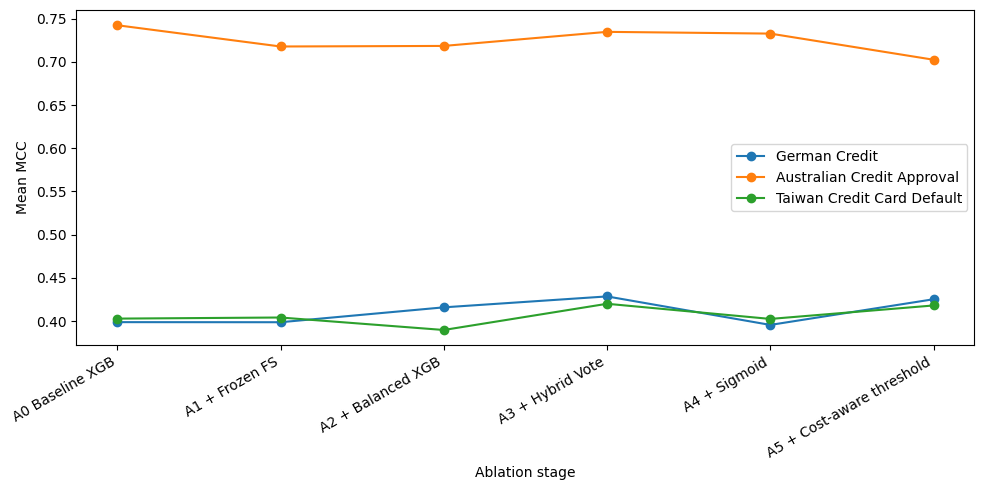

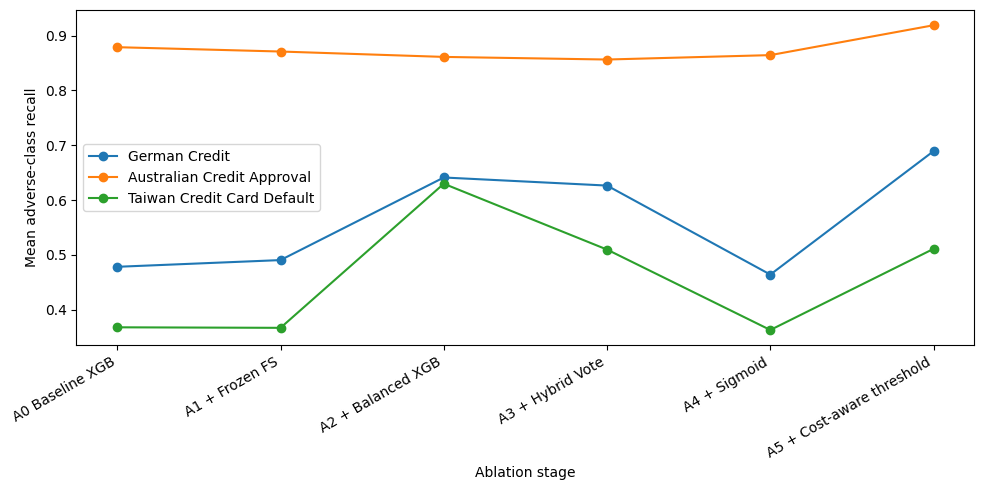

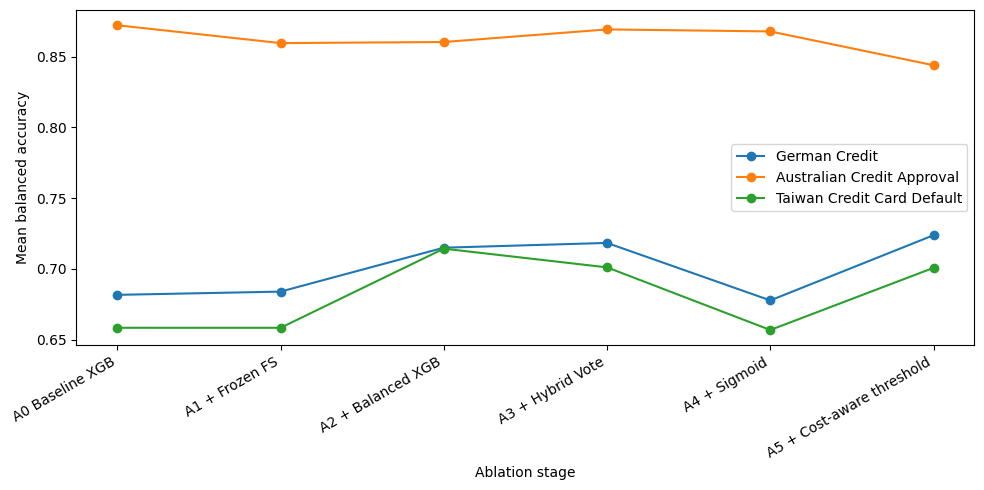

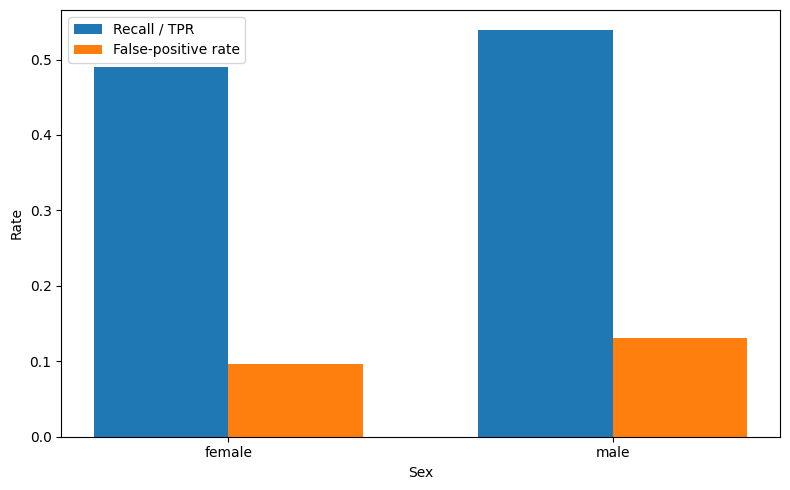

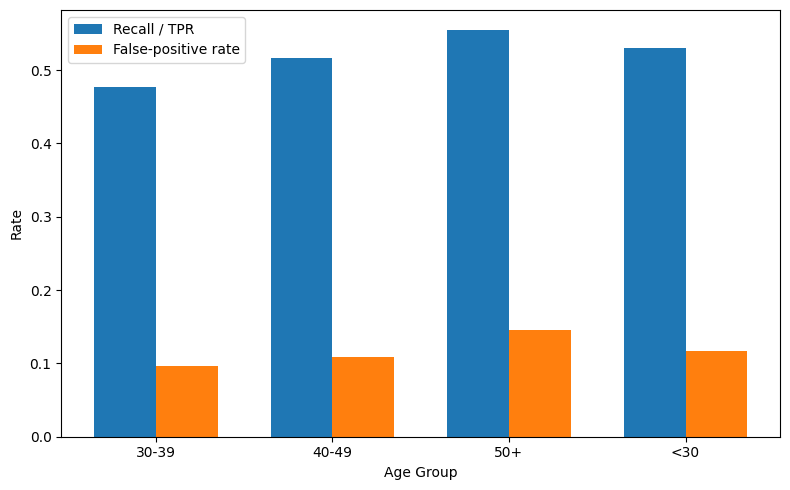

In [12]:

# Figure 1: MCC ablation
for metric, ylabel, filename in [
    (
        "MCC",
        "Mean MCC",
        "ablation_mcc.png",
    ),
    (
        "Recall",
        "Mean adverse-class recall",
        "ablation_recall.png",
    ),
    (
        "Balanced_Accuracy",
        "Mean balanced accuracy",
        "ablation_balanced_accuracy.png",
    ),
]:
    plt.figure(
        figsize=(
            10,
            5,
        )
    )

    for dataset_name in DATASET_ORDER:
        temp = (
            ablation_summary[
                ablation_summary[
                    "dataset"
                ]
                == dataset_name
            ]
            .copy()
        )

        temp = temp.set_index(
            "stage"
        ).reindex(
            STAGE_ORDER
        )

        plt.plot(
            range(
                len(
                    STAGE_ORDER
                )
            ),
            temp[
                metric
            ].to_numpy(),
            marker="o",
            label=dataset_name,
        )

    plt.xticks(
        range(
            len(
                STAGE_ORDER
            )
        ),
        [
            STAGE_LABELS[
                stage
            ]
            for stage
            in STAGE_ORDER
        ],
        rotation=30,
        ha="right",
    )

    plt.ylabel(
        ylabel
    )
    plt.xlabel(
        "Ablation stage"
    )
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        FIG_DIR
        / filename,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()


# Figure 2: Taiwan fairness group recall
for attribute, filename in [
    (
        "sex",
        "taiwan_fairness_sex.png",
    ),
    (
        "age_group",
        "taiwan_fairness_age.png",
    ),
]:
    temp = (
        fairness_group_summary[
            fairness_group_summary[
                "attribute"
            ]
            == attribute
        ]
        .copy()
    )

    x = np.arange(
        len(
            temp
        )
    )

    width = 0.35

    plt.figure(
        figsize=(
            8,
            5,
        )
    )

    plt.bar(
        x
        - width / 2,
        temp[
            "Recall_TPR"
        ],
        width,
        label="Recall / TPR",
    )

    plt.bar(
        x
        + width / 2,
        temp[
            "False_Positive_Rate"
        ],
        width,
        label="False-positive rate",
    )

    plt.xticks(
        x,
        temp[
            "group"
        ],
    )

    plt.ylabel(
        "Rate"
    )
    plt.xlabel(
        attribute.replace(
            "_",
            " ",
        ).title()
    )
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        FIG_DIR
        / filename,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()


## 11. Final framework manuscript table

In [ ]:

final_table = (
    ablation_summary[
        ablation_summary[
            "stage"
        ]
        == "A5_Full_CostAware"
    ]
    [
        [
            "dataset",
            "ROC_AUC",
            "PR_AUC",
            "Recall",
            "Precision",
            "F1",
            "Balanced_Accuracy",
            "MCC",
            "GMean",
            "Cost_2_1",
            "Cost_5_1",
            "Cost_10_1",
        ]
    ]
    .copy()
)

calibrated_only = (
    calibration_summary[
        calibration_summary[
            "calibration_method"
        ]
        == "Sigmoid"
    ]
    [
        [
            "dataset",
            "Brier",
            "LogLoss",
            "ECE",
            "Calibration_Intercept",
            "Calibration_Slope",
        ]
    ]
)

final_table = final_table.merge(
    calibrated_only,
    on="dataset",
    how="left",
    validate="one_to_one",
)

final_table.to_csv(
    OUT_DIR / "final_framework_cross_dataset_table.csv",
    index=False,
)

display(final_table)


## 12. Final consistency checks and manifest

Step 13 does not alter any trained architecture or selection rule.

After reviewing these results, the next notebook should perform **model-agnostic source-feature permutation importance for the full hybrid**, with optional component-level SHAP analysis for XGBoost. That explanation stage should be kept separate from this statistical/fairness audit so that the manuscript can distinguish performance evidence from interpretability evidence.


In [ ]:

expected_ablation_rows = (
    3
    * 6
    * 25
)

assert len(
    ablation_fold
) == expected_ablation_rows

assert len(
    ablation_summary
) == 3 * 6

assert len(
    final_vs_baseline
) == 3

assert len(
    corrected_statistics
) == (
    3
    * len(
        STAT_METRICS
    )
)

assert set(
    fairness_group_summary[
        "attribute"
    ].unique()
) == {
    "sex",
    "age_group",
}

configuration = {
    "stage": (
        "Objective 3 Step 13 - final ablation, "
        "corrected statistics, and fairness audit"
    ),
    "framework_status": "frozen",
    "ablation_stages": STAGE_ORDER,
    "primary_final_comparator": (
        "All-feature unweighted XGBoost baseline"
    ),
    "statistical_test": (
        "Nadeau-Bengio corrected repeated-CV t-test"
    ),
    "multiple_testing_correction": (
        "Holm adjustment within each dataset"
    ),
    "fairness_dataset": (
        "Taiwan Credit Card Default"
    ),
    "fairness_attributes": [
        "sex",
        "age_group",
    ],
    "fairness_interpretation": (
        "Descriptive audit only; no universal fairness claim"
    ),
    "cost_interpretation": (
        "FN:FP=2:1 is a reference asymmetric-loss scenario, "
        "not actual bank monetary cost"
    ),
}

with open(
    OUT_DIR / "step13_experiment_configuration.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        configuration,
        file,
        indent=4,
    )

manifest = sorted(
    [
        path.relative_to(
            OUT_DIR
        ).as_posix()
        for path
        in OUT_DIR.rglob("*")
        if path.is_file()
    ]
)

pd.DataFrame(
    {
        "generated_file": manifest
    }
).to_csv(
    OUT_DIR / "step13_output_manifest.csv",
    index=False,
)

print("=" * 80)
print("STEP 13 COMPLETED SUCCESSFULLY")
print("=" * 80)
print("Output folder:", OUT_DIR)
print("\nMost important files:")
print(" - final_framework_cross_dataset_table.csv")
print(" - manuscript_ready_ablation_table.csv")
print(" - final_framework_vs_baseline_summary.csv")
print(" - final_vs_baseline_corrected_statistics.csv")
print(" - cross_dataset_calibration_table.csv")
print(" - taiwan_fairness_group_summary.csv")
print(" - taiwan_fairness_gap_summary.csv")
print(" - figures/")
